# A/B 测试从 0 到 1 完整实战 (轻量版)
> **场景**: 某电商平台测试新推荐算法对购买转化率 (CVR) 的影响
>
> **数据**: 模拟数据 (已分好组，开箱即用)
>
> **目标**: 走完 A/B 测试 SOP 全链路：SRM → 样本量 → T-Test → CI → 可视化 → 业务决策

---
## Module 0: 环境配置 & 数据生成

直接运行下面这个 Cell，生成模拟数据。

In [1]:
# ===== 环境配置 =====
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.stats.api as sms
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
import matplotlib.pyplot as plt
import seaborn as sns

# 中文字体配置
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.float_format', '{:.4f}'.format)

# ===== 模拟数据生成 =====
np.random.seed(42)

# 实验参数
N_PER_GROUP = 10000  # 每组 10000 用户
CVR_CONTROL = 0.10   # 对照组 CVR = 10%
CVR_TREATMENT = 0.11 # 实验组 CVR = 11% (提升 1pp)

# 生成数据
def generate_ab_data(n, cvr_ctrl, cvr_treat):
    """生成已分好组的 A/B 测试模拟数据"""
    groups = np.array(['control'] * n + ['treatment'] * n)
    probs = np.where(groups == 'control', cvr_ctrl, cvr_treat)
    is_purchased = np.random.binomial(1, probs)
    
    # 收入: 购买用户 ~ N(150, 30), 未购买 = 0
    revenue = np.where(is_purchased == 1,
                       np.maximum(np.random.normal(150, 30, len(groups)), 0), 0)
    
    # 页面浏览量 ~ Poisson(12)
    page_views = np.random.poisson(12, len(groups))
    
    # 实验前历史 CVR ~ N(0.09, 0.03), 截断到 [0, 1]
    pre_cvr = np.clip(np.random.normal(0.09, 0.03, len(groups)), 0, 1)
    
    return pd.DataFrame({
        'user_id': range(1, 2*n + 1),
        'group': groups,
        'is_purchased': is_purchased,
        'revenue': np.round(revenue, 2),
        'page_views': page_views,
        'pre_cvr': np.round(pre_cvr, 4)
    })

df = generate_ab_data(N_PER_GROUP, CVR_CONTROL, CVR_TREATMENT)

print(f"数据形状: {df.shape}")
print(f"\n各组样本量:")
print(df['group'].value_counts())
print(f"\n各组 CVR:")
print(df.groupby('group')['is_purchased'].mean())
df.head()

数据形状: (20000, 6)

各组样本量:
group
control      10000
treatment    10000
Name: count, dtype: int64

各组 CVR:
group
control     0.0961
treatment   0.1130
Name: is_purchased, dtype: float64


,user_id,group,is_purchased,revenue,page_views,pre_cvr
0,1,control,0,0.0000,5,0.1389
1,2,control,1,167.5800,9,0.1101
2,3,control,0,0.0000,7,0.0939
3,4,control,0,0.0000,4,0.1166
4,5,control,0,0.0000,9,0.0722


---
## Module 1: 商业背景 & 假设定义

### 业务场景
我们是某电商平台的数据分析师。算法团队上线了一个**新的推荐算法 v2**，声称能通过更精准的商品推荐来提高用户的购买转化率 (CVR)。

### 实验设计
| 项目 | 内容 |
|:---|:---|
| **核心指标 (Primary Metric)** | CVR = 购买用户数 / 总用户数 |
| **护栏指标 (Guardrail Metrics)** | ARPU (人均收入), 人均浏览量 |
| **H₀ (原假设)** | 新算法对 CVR 没有显著影响 (μ_treatment = μ_control) |
| **H₁ (备择假设)** | 新算法对 CVR 有显著影响 (μ_treatment ≠ μ_control) |
| **显著性水平 α** | 0.05 |
| **统计功效 Power** | 0.80 |

---
## Module 2: SRM 检测 (Sample Ratio Mismatch)

在分析实验结果之前，**第一步永远是检查分流是否正常**。

如果实验设计是 50:50 分流，但实际观察到的比例偏差很大（如 52:48），说明分流系统可能有 Bug，后续分析全部无效。

**方法**: 卡方检验 (`scipy.stats.chisquare`)

```python
# 提示: 
# observed = [对照组人数, 实验组人数]
# expected = [期望对照组人数, 期望实验组人数]  (50:50 就是各一半)
# stat, p_value = stats.chisquare(observed, expected)
```

In [8]:
# 🏋️ 你的代码: SRM 检测
control_group = df[df['group'] == 'control']
treatment_group = df[df['group'] == 'treatment']

observed = [control_group['user_id'].nunique(), treatment_group['user_id'].nunique()]
expected = [df['user_id'].nunique() / 2, df['user_id'].nunique() / 2]

stat,p_value = stats.chisquare(observed, expected)

print(f"卡方统计量: {stat:.4f}, P-value: {p_value:.4f}")

result = "分流有明显差异！" if p_value < 0.05 else "分流正常"

print(f'{result}')



卡方统计量: 0.0000, P-value: 1.0000
分流正常


In [ ]:
# # ✅ 参考答案: SRM 检测
# n_control = df[df['group'] == 'control'].shape[0]
# n_treatment = df[df['group'] == 'treatment'].shape[0]
# n_total = n_control + n_treatment

# # 期望 50:50 分流
# observed = [n_control, n_treatment]
# expected = [n_total / 2, n_total / 2]

# stat, p_value = stats.chisquare(observed, expected)

# print(f"对照组: {n_control}, 实验组: {n_treatment}")
# print(f"卡方统计量: {stat:.4f}")
# print(f"P-value: {p_value:.4f}")
# print(f"\n结论: {'⚠️ 存在 SRM！分流异常！' if p_value < 0.05 else '✅ 分流正常，无 SRM'}")

---
## Module 3: 样本量计算 (MDE / Power Analysis)

虽然实验已经跑完了，但回溯性的 Power Analysis 能帮你判断：**当前样本量够不够检测到 1pp 的提升？**

```python
# 提示:
# 1. 计算 Effect Size: proportion_effectsize(p1, p2)
# 2. 计算所需样本量: NormalIndPower().solve_power(
#        effect_size=..., alpha=0.05, power=0.80, 
#        ratio=1, alternative='two-sided')
```

In [17]:
# 🏋️ 你的代码: 样本量计算
p1 = 0.0961
p2 = p1+0.01

effect_size = sms.proportion_effectsize(p1,p2)

n_required = NormalIndPower().solve_power(
    effect_size=effect_size, 
    power=0.8, 
    alpha=0.05
    )

print(f'每组需要样本:{int(n_required)}')

result_2 = '样本量充足' if n_required <= treatment_group['user_id'].nunique() else '样本量不足'
gap = treatment_group['user_id'].nunique() - n_required

print(f'{result_2}')
print(f'样本量差值: {int(gap)}')



每组需要样本:14257
样本量不足
样本量差值: -4257


In [15]:
# ✅ 参考答案: 样本量计算
p1 = CVR_CONTROL     # 基线 CVR = 10%
p2 = CVR_TREATMENT   # 目标 CVR = 11%

# 1. 计算 Effect Size (Cohen's h)
effect_size = proportion_effectsize(p1, p2)
print(f"Effect Size (Cohen's h): {effect_size:.4f}")

# 2. 计算每组所需最小样本量
power_analysis = NormalIndPower()
required_n = power_analysis.solve_power(
    effect_size=abs(effect_size),
    alpha=0.05,
    power=0.80,
    ratio=1,
    alternative='two-sided'
)

print(f"每组所需最小样本量: {int(np.ceil(required_n)):,}")
print(f"当前每组实际样本量: {N_PER_GROUP:,}")
print(f"\n结论: {'✅ 样本量充足' if N_PER_GROUP >= required_n else '⚠️ 样本量不足，需要延长实验'}")

Effect Size (Cohen's h): -0.0326
每组所需最小样本量: 14,745
当前每组实际样本量: 10,000

结论: ⚠️ 样本量不足，需要延长实验


---
## Module 4: 显著性检验 (T-Test)

核心问题：**两组 CVR 的差异是否具有统计显著性？**

```python
# 提示:
# control_cvr = df[df['group'] == 'control']['is_purchased']
# treatment_cvr = df[df['group'] == 'treatment']['is_purchased']
# t_stat, p_value = stats.ttest_ind(control_cvr, treatment_cvr)
```

In [24]:
# 🏋️ 你的代码: T-Test
control_cvr = control_group['is_purchased'].sum() / control_group['user_id'].nunique()
treatment_cvr = treatment_group['is_purchased'].sum() / treatment_group['user_id'].nunique()

print(f"Control CVR: {control_cvr:.4f}")
print(f"Treatment CVR: {treatment_cvr:.4f}")

stat, p_value = stats.ttest_ind(control_group['is_purchased'], treatment_group['is_purchased'])

uplift = treatment_cvr - control_cvr
print(f"T-Test {stat:.4f}, P-value: {p_value:.4f}")

result = "Treatment CVR 显著高于 Control,新算法有效建议采纳" if p_value < 0.05 else "Treatment CVR 与 Control 没有显著差异"

print(f'{result},效果{uplift:.4%}')


Control CVR: 0.0961
Treatment CVR: 0.1130
T-Test -3.9069, P-value: 0.0001
Treatment CVR 显著高于 Control,新算法有效建议采纳,效果1.6900%


In [19]:
# ✅ 参考答案: T-Test
control = df[df['group'] == 'control']['is_purchased']
treatment = df[df['group'] == 'treatment']['is_purchased']

t_stat, p_value = stats.ttest_ind(control, treatment)

print(f"对照组 CVR: {control.mean():.4f}")
print(f"实验组 CVR: {treatment.mean():.4f}")
print(f"CVR 差异 (Lift): {treatment.mean() - control.mean():.4f} ({(treatment.mean() - control.mean()) / control.mean():.2%})")
print(f"\nT 统计量: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"\n结论: {'✅ 显著！拒绝 H₀，新算法有效' if p_value < 0.05 else '❌ 不显著，无法拒绝 H₀'}")

对照组 CVR: 0.0961
实验组 CVR: 0.1130
CVR 差异 (Lift): 0.0169 (17.59%)

T 统计量: -3.9069
P-value: 0.0001

结论: ✅ 显著！拒绝 H₀，新算法有效


---
## Module 5: 置信区间 (Confidence Interval)

P-value 只告诉你"是否显著"，**置信区间告诉你"效果有多大"**。

```python
# 提示:
# cm = sms.CompareMeans(
#     sms.DescrStatsW(treatment), 
#     sms.DescrStatsW(control)
# )
# ci_lower, ci_upper = cm.tconfint_diff(usevar='unequal', alpha=0.05)
```

In [29]:
# 🏋️ 你的代码: 置信区间
cm = sms.CompareMeans(
    sms.DescrStatsW(treatment), 
    sms.DescrStatsW(control)
)

ci_lower,ci_upper = cm.tconfint_diff(usevar='unequal',alpha = 0.05)

diff = treatment.mean() - control.mean()


print(f"CVR 差异 (Treatment - Control): {diff:.4%}")
print(f"95% 置信区间: [{ci_lower:.4%}, {ci_upper:.4%}]")
print(f"\n解读: 我们有 95% 的信心认为，新算法带来的 CVR 提升在 {ci_lower:.4%} 到 {ci_upper:.4%} 之间。")
print(f"{'✅ CI 不包含 0 → 显著' if ci_lower > 0 or ci_upper < 0 else '❌ CI 包含 0 → 不显著'}")

CVR 差异 (Treatment - Control): 1.6900%
95% 置信区间: [0.8421%, 2.5379%]

解读: 我们有 95% 的信心认为，新算法带来的 CVR 提升在 0.8421% 到 2.5379% 之间。
✅ CI 不包含 0 → 显著


In [25]:
# ✅ 参考答案: 置信区间
cm = sms.CompareMeans(
    sms.DescrStatsW(treatment), 
    sms.DescrStatsW(control)
)

ci_lower, ci_upper = cm.tconfint_diff(usevar='unequal', alpha=0.05)
diff = treatment.mean() - control.mean()

print(f"CVR 差异 (Treatment - Control): {diff:.4f}")
print(f"95% 置信区间: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"\n解读: 我们有 95% 的信心认为，新算法带来的 CVR 提升在 {ci_lower:.4f} 到 {ci_upper:.4f} 之间。")
print(f"{'✅ CI 不包含 0 → 显著' if ci_lower > 0 or ci_upper < 0 else '❌ CI 包含 0 → 不显著'}")

CVR 差异 (Treatment - Control): 0.0169
95% 置信区间: [0.0084, 0.0254]

解读: 我们有 95% 的信心认为，新算法带来的 CVR 提升在 0.0084 到 0.0254 之间。
✅ CI 不包含 0 → 显著


---
## Module 6: 结果可视化

画一张带误差棒 (Error Bar) 的柱状图，一目了然地展示两组 CVR 的差异和置信区间。

```python
# 提示:
# 1. 计算两组 CVR 的均值和标准误差 (SE = std / sqrt(n))
# 2. 使用 plt.bar() 画柱状图
# 3. 使用 yerr 参数添加误差棒
# 4. 添加数值标注 plt.text()
```

In [ ]:
# 🏋️ 你的代码: 可视化



/var/folders/35/q6rh83x91bzgf3gcsb_13f_80000gn/T/ipykernel_26352/2495902386.py:35: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Arial Unicode MS.
  plt.tight_layout()
./.pyenv/versions/3.12.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Arial Unicode MS.
  fig.canvas.print_figure(bytes_io, **kw)


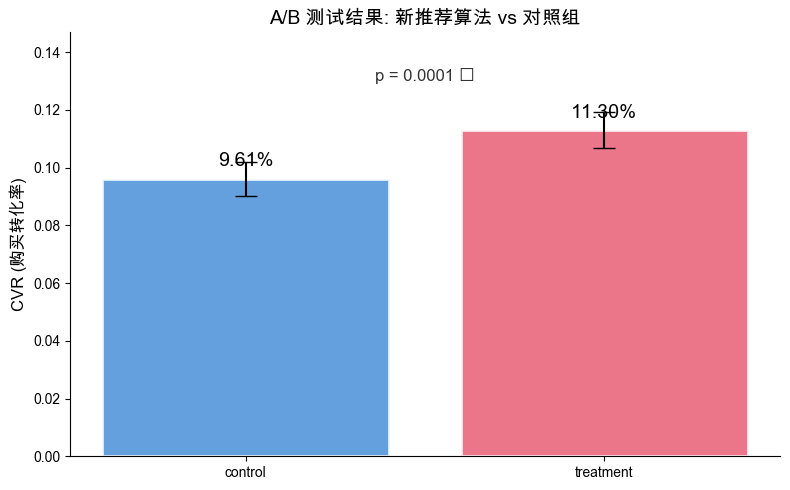

In [26]:
# ✅ 参考答案: 可视化
# 计算每组的 CVR 和 SE
group_stats = df.groupby('group')['is_purchased'].agg(['mean', 'std', 'count'])
group_stats['se'] = group_stats['std'] / np.sqrt(group_stats['count'])

# 绘图
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#4A90D9', '#E85D75']
bars = ax.bar(
    group_stats.index, 
    group_stats['mean'], 
    yerr=1.96 * group_stats['se'],  # 95% CI 误差棒
    capsize=8, 
    color=colors, 
    edgecolor='white',
    linewidth=2,
    alpha=0.85
)

# 添加数值标注
for bar, cvr in zip(bars, group_stats['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{cvr:.2%}', ha='center', va='bottom', fontsize=14, fontweight='bold')

ax.set_ylabel('CVR (购买转化率)', fontsize=12)
ax.set_title('A/B 测试结果: 新推荐算法 vs 对照组', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(group_stats['mean']) * 1.3)
ax.spines[['top', 'right']].set_visible(False)

# 标注统计显著性
sig_text = f'p = {p_value:.4f} {"⭐" if p_value < 0.05 else ""}'
ax.annotate(sig_text, xy=(0.5, max(group_stats['mean']) * 1.15),
            fontsize=12, ha='center', color='#333')

plt.tight_layout()
plt.show()

---
## Module 7: 护栏指标检查 (Guardrail Metrics)

即使核心指标 CVR 提升了，也需要确认护栏指标没有"翻车"：
- **ARPU (人均收入)**: 不能因为推低价商品而拉高 CVR
- **人均浏览量**: 不能因为弹窗骚扰而降低浏览体验

```python
# 提示: 分别对 revenue 和 page_views 做 T-Test
```

In [ ]:
# 🏋️ 你的代码: 护栏指标检查



In [27]:
# ✅ 参考答案: 护栏指标检查
guardrail_metrics = ['revenue', 'page_views']
guardrail_names = ['人均收入 (ARPU)', '人均浏览量']

print("=" * 50)
print("护栏指标检查报告")
print("=" * 50)

for metric, name in zip(guardrail_metrics, guardrail_names):
    ctrl = df[df['group'] == 'control'][metric]
    treat = df[df['group'] == 'treatment'][metric]
    
    t, p = stats.ttest_ind(ctrl, treat)
    
    status = '✅ 安全' if p >= 0.05 else '⚠️ 异常！'
    print(f"\n📊 {name}:")
    print(f"   对照组: {ctrl.mean():.4f}")
    print(f"   实验组: {treat.mean():.4f}")
    print(f"   P-value: {p:.4f} → {status}")

护栏指标检查报告

📊 人均收入 (ARPU):
   对照组: 14.3302
   实验组: 16.9593
   P-value: 0.0001 → ⚠️ 异常！

📊 人均浏览量:
   对照组: 12.0428
   实验组: 11.9791
   P-value: 0.1955 → ✅ 安全


---
## Module 8: 业务决策报告 (Go/No-Go)

请根据以上分析结果，填写下面的决策报告（双击编辑本 Cell）：

---

### 📋 A/B 测试决策报告

| 项目 | 结果 |
|:---|:---|
| **实验名称** | 推荐算法 v2 |
| **实验周期** | 2025-02-18 ~ 2025-02-25 |
| **SRM 检测** | P = ___ → 分流（正常/异常） |
| **核心指标 CVR** | 对照组 ___% → 实验组 ___% (提升 ___pp) |
| **统计显著性** | P = ___, 95% CI = [___, ___] |
| **护栏指标 ARPU** | P = ___ → （安全/异常） |
| **护栏指标 浏览量** | P = ___ → （安全/异常） |

### 🎯 决策
- [ ] **Go**: 全量上线新算法
- [ ] **No-Go**: 回滚，需进一步优化
- [ ] **继续实验**: 样本量不足，延长观察

### 💡 建议
_（请在此写下你的业务建议，例如：建议全量上线，同时持续监控 ARPU 指标...）_